# Paddy Leaf Disease Classification — ConvNeXt-Tiny (thermal images)

Same dataset and same overall pipeline (download → split → transform → train → evaluate)
as the ViT-Base version, swapped to **ConvNeXt-Tiny** (a modern conv-net rather than a
transformer) with a few extra training features:
- Label smoothing on the loss
- Cosine-annealing LR schedule
- Mixed-precision (AMP) training
- Gradient clipping
- Early stopping on validation loss
- Per-class accuracy bar chart at the end

**Deployment-ready update:** replaced the deprecated `torch.cuda.amp.autocast` /
`torch.cuda.amp.GradScaler` calls with the current `torch.amp` API (avoids `FutureWarning`
on recent PyTorch/Colab), and added a final cell to download the trained model package so
it can be used outside Colab (e.g. in a Streamlit app — see the deployment section at the
end of this notebook).


In [12]:
import kagglehub# Download latest versionpath = kagglehub.dataset_download("sujaradha/thermal-images-diseased-healthy-leaves-paddy")print("Path to dataset files:", path)

In [13]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bmshahriaalam/tealeafbd-tea-leaf-disease-detection")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'tealeafbd-tea-leaf-disease-detection' dataset.
Path to dataset files: /kaggle/input/tealeafbd-tea-leaf-disease-detection


In [14]:
import os

for root, dirs, files in os.walk(path):
    print(root, "→", len(files), "files")

/kaggle/input/tealeafbd-tea-leaf-disease-detection → 0 files
/kaggle/input/tealeafbd-tea-leaf-disease-detection/teaLeafBD → 0 files
/kaggle/input/tealeafbd-tea-leaf-disease-detection/teaLeafBD/teaLeafBD → 0 files
/kaggle/input/tealeafbd-tea-leaf-disease-detection/teaLeafBD/teaLeafBD/3. Gray Blight → 1013 files
/kaggle/input/tealeafbd-tea-leaf-disease-detection/teaLeafBD/teaLeafBD/2. Brown Blight → 506 files
/kaggle/input/tealeafbd-tea-leaf-disease-detection/teaLeafBD/teaLeafBD/7. Healthy leaf → 935 files
/kaggle/input/tealeafbd-tea-leaf-disease-detection/teaLeafBD/teaLeafBD/6. Green mirid bug → 1282 files
/kaggle/input/tealeafbd-tea-leaf-disease-detection/teaLeafBD/teaLeafBD/1. Tea algal leaf spot → 418 files
/kaggle/input/tealeafbd-tea-leaf-disease-detection/teaLeafBD/teaLeafBD/4. Helopeltis → 607 files
/kaggle/input/tealeafbd-tea-leaf-disease-detection/teaLeafBD/teaLeafBD/5. Red spider → 515 files


In [17]:
dataset_dir = os.path.join(path, "teaLeafBD", "teaLeafBD")
for class_name in os.listdir(dataset_dir):
    class_path = os.path.join(dataset_dir, class_name)
    if os.path.isdir(class_path):
        files = os.listdir(class_path)
        print("\nCLASS:", class_name)
        print("Number of files:", len(files))
        print("First 5 files:", files[:5])


CLASS: 3. Gray Blight
Number of files: 1013
First 5 files: ['gray_blight_00606.jpg', 'gray_blight_00901.jpg', 'gray_blight_00248.jpg', 'gray_blight_00705.jpg', 'gray_blight_00557.jpg']

CLASS: 2. Brown Blight
Number of files: 506
First 5 files: ['brown_blight_00359.jpg', 'brown_blight_00340.jpg', 'brown_blight_00167.jpg', 'brown_blight_00354.jpg', 'brown_blight_00236.jpg']

CLASS: 7. Healthy leaf
Number of files: 935
First 5 files: ['healthy_00085.jpg', 'healthy_00051.jpg', 'healthy_00041.jpg', 'healthy_00639.jpg', 'healthy_00635.jpg']

CLASS: 6. Green mirid bug
Number of files: 1282
First 5 files: ['green_mirid_bug_00339.jpg', 'green_mirid_bug_00653.jpg', 'green_mirid_bug_00340.jpg', 'green_mirid_bug_00733.jpg', 'green_mirid_bug_00030.jpg']

CLASS: 1. Tea algal leaf spot
Number of files: 418
First 5 files: ['tea_algal_leaf_spot_00177.jpg', 'tea_algal_leaf_spot_00315.jpg', 'tea_algal_leaf_spot_00396.jpg', 'tea_algal_leaf_spot_00319.jpg', 'tea_algal_leaf_spot_00227.jpg']

CLASS: 4. Hel

In [19]:
from PIL import Image

for class_name in os.listdir(dataset_dir):
    class_path = os.path.join(dataset_dir, class_name)
    if not os.path.isdir(class_path):
        continue
    for filename in os.listdir(class_path):
        file_path = os.path.join(class_path, filename)
        try:
            img = Image.open(file_path)
            print(class_name, "->", filename, "-> size:", img.size, "-> mode:", img.mode)
            break
        except Exception as e:
            print("Could not open:", file_path, e)

3. Gray Blight -> gray_blight_00606.jpg -> size: (1200, 1600) -> mode: RGB
2. Brown Blight -> brown_blight_00359.jpg -> size: (1200, 1600) -> mode: RGB
7. Healthy leaf -> healthy_00085.jpg -> size: (1200, 904) -> mode: RGB
6. Green mirid bug -> green_mirid_bug_00339.jpg -> size: (1200, 1594) -> mode: RGB
1. Tea algal leaf spot -> tea_algal_leaf_spot_00177.jpg -> size: (1200, 1600) -> mode: RGB
4. Helopeltis -> helopeltis_00149.jpg -> size: (1200, 1600) -> mode: RGB
5. Red spider -> red_spider_00275.jpg -> size: (1200, 1600) -> mode: RGB


In [21]:
import shutil
from sklearn.model_selection import train_test_split

# Original dataset
source_dir = os.path.join(path, "teaLeafBD", "teaLeafBD")

# New dataset location
output_dir = "/content/tea_leaf_dataset"

# Classes (dynamically get from source_dir)
classes = [d for d in os.listdir(source_dir) if os.path.isdir(os.path.join(source_dir, d))]
classes.sort() # Ensure consistent order

# Split ratios (parameterized so they're easy to tweak — original used fixed 70/15/15)
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# Create folders
for split in ["train", "val", "test"]:
    for class_name in classes:
        os.makedirs(os.path.join(output_dir, split, class_name), exist_ok=True)

# Split and copy images
for class_name in classes:
    class_dir = os.path.join(source_dir, class_name)
    files = [f for f in os.listdir(class_dir) if os.path.isfile(os.path.join(class_dir, f))]
    train_files, temp_files = train_test_split(
        files,
        test_size=(1 - TRAIN_RATIO),
        random_state=42
    )
    val_files, test_files = train_test_split(
        temp_files,
        test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),
        random_state=42
    )
    for filename in train_files:
        shutil.copy(os.path.join(class_dir, filename), os.path.join(output_dir, "train", class_name, filename))
    for filename in val_files:
        shutil.copy(os.path.join(class_dir, filename), os.path.join(output_dir, "val", class_name, filename))
    for filename in test_files:
        shutil.copy(os.path.join(class_dir, filename), os.path.join(output_dir, "test", class_name, filename))
print("Dataset split completed!")

Dataset split completed!


In [22]:
for split in ["train", "val", "test"]:
   print("\n", split.upper())
for class_name in classes:
   folder = os.path.join(output_dir, split, class_name)
   count = len(os.listdir(folder))
   print(f"{class_name:15} -> {count}")


 TRAIN

 VAL

 TEST
1. Tea algal leaf spot -> 63
2. Brown Blight -> 76
3. Gray Blight  -> 152
4. Helopeltis   -> 92
5. Red spider   -> 78
6. Green mirid bug -> 193
7. Healthy leaf -> 141


In [24]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [25]:
IMG_SIZE = 224# Slightly richer augmentation than the ViT version: added ColorJitter and a mild# RandomResizedCrop instead of a plain Resize, since ConvNeXt tends to benefit from it.train_transform = transforms.Compose([    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),    transforms.RandomHorizontalFlip(),    transforms.RandomRotation(10),    transforms.ColorJitter(brightness=0.15, contrast=0.15),    transforms.ToTensor(),    transforms.Normalize(        mean=[0.485, 0.456, 0.406],        std=[0.229, 0.224, 0.225]    )])

In [27]:
val_test_transform = transforms.Compose([    transforms.Resize((IMG_SIZE, IMG_SIZE)),    transforms.ToTensor(),    transforms.Normalize(        mean=[0.485, 0.456, 0.406],        std=[0.229, 0.224, 0.225]    )])

In [30]:
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )])

train_dataset = datasets.ImageFolder(os.path.join(output_dir, "train"), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(output_dir, "val"), transform=val_test_transform)
test_dataset = datasets.ImageFolder(os.path.join(output_dir, "test"), transform=val_test_transform)

In [31]:
print(train_dataset.classes)
print(train_dataset.class_to_idx)

['1. Tea algal leaf spot', '2. Brown Blight', '3. Gray Blight', '4. Helopeltis', '5. Red spider', '6. Green mirid bug', '7. Healthy leaf']
{'1. Tea algal leaf spot': 0, '2. Brown Blight': 1, '3. Gray Blight': 2, '4. Helopeltis': 3, '5. Red spider': 4, '6. Green mirid bug': 5, '7. Healthy leaf': 6}


In [35]:
# Larger batch size than the ViT version (32 vs 16) and a couple of loader workers
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

images, labels = next(iter(train_loader))
print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels)

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Labels: tensor([5, 3, 4, 6, 5, 2, 5, 2, 1, 0, 2, 6, 3, 6, 1, 2, 6, 0, 2, 5, 4, 2, 0, 5,
        2, 0, 5, 5, 5, 3, 0, 5])


In [36]:
!pip install -q timm

In [39]:
import timm
import torch
import torch.nn as nn

In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
  print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [41]:
num_classes = len(train_dataset.classes)# Different model family: ConvNeXt-Tiny (conv-based) instead of ViT-Base (transformer).

In [50]:
# Smaller and faster to train (~28M params vs ~86M for vit_base_patch16_224).
model = timm.create_model(
    "convnext_tiny",
    pretrained=True,
    num_classes=num_classes)
model = model.to(device)
num_params = sum(p.numel() for p in model.parameters())
num_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {num_params:,}")
print(f"Trainable parameters: {num_trainable:,}")
images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)
outputs = model(images)
print("Input shape:", images.shape)
print("Output shape:", outputs.shape)

model.safetensors: reconstructing file:   0%|          |  0.00B /  114MB            

model.safetensors: downloading bytes:           |  0.00B            

Total parameters: 27,825,511
Trainable parameters: 27,825,511
Input shape: torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 7])


In [58]:
# Extra features vs. the ViT version: label smoothing on the loss, a cosine LR
# schedule, and a slightly higher starting LR since ConvNeXt trains a bit faster.
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.AdamW(model.parameters(),lr=3e-4,weight_decay=0.05)

num_epochs = 10

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=num_epochs)

# Mixed-precision training (updated to the current, non-deprecated torch.amp API)
scaler = torch.amp.GradScaler(device.type, enabled=(device.type == "cuda"))


In [59]:
model.train()

images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

optimizer.zero_grad()

with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
    outputs = model(images)
    loss = criterion(outputs, labels)

scaler.scale(loss).backward()
scaler.step(optimizer)
scaler.update()

print("Loss:", loss.item())


Loss: 0.4942646622657776


In [60]:
from sklearn.metrics import accuracy_score

best_val_accuracy = 0.0

# Early stopping on validation loss (not in the ViT version) — extra parameter
early_stop_patience = 5
epochs_without_improvement = 0
best_val_loss = float("inf")

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):

    # TRAINING
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        # Gradient clipping (not in the ViT version)
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / total
    train_accuracy = correct / total

    # VALIDATION
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
                outputs = model(images)
                loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = running_loss / total
    val_accuracy = correct / total

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    # Save best model (by val accuracy, same rule as the ViT version)
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(model.state_dict(), "/content/best_convnext.pth")

    # Early stopping bookkeeping (extra vs. ViT version)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy*100:.2f}% "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy*100:.2f}% "
        f"LR: {current_lr:.2e}"
    )

    if epochs_without_improvement >= early_stop_patience:
        print(f"\nEarly stopping triggered after epoch {epoch+1} (no val-loss improvement for {early_stop_patience} epochs).")
        break

print("\nBest Validation Accuracy:", best_val_accuracy * 100, "%")

Epoch [1/10] Train Loss: 0.6998 Train Acc: 89.35% Val Loss: 0.7567 Val Acc: 85.34% LR: 2.93e-04
Epoch [2/10] Train Loss: 0.6570 Train Acc: 90.73% Val Loss: 0.7651 Val Acc: 86.35% LR: 2.71e-04
Epoch [3/10] Train Loss: 0.6141 Train Acc: 92.74% Val Loss: 0.8504 Val Acc: 81.92% LR: 2.38e-04
Epoch [4/10] Train Loss: 0.6016 Train Acc: 93.01% Val Loss: 0.7444 Val Acc: 87.61% LR: 1.96e-04
Epoch [5/10] Train Loss: 0.5704 Train Acc: 94.80% Val Loss: 0.6842 Val Acc: 89.63% LR: 1.50e-04
Epoch [6/10] Train Loss: 0.5211 Train Acc: 96.99% Val Loss: 0.7374 Val Acc: 88.12% LR: 1.04e-04
Epoch [7/10] Train Loss: 0.5003 Train Acc: 97.67% Val Loss: 0.6781 Val Acc: 90.77% LR: 6.18e-05
Epoch [8/10] Train Loss: 0.4761 Train Acc: 98.89% Val Loss: 0.6665 Val Acc: 91.66% LR: 2.86e-05
Epoch [9/10] Train Loss: 0.4606 Train Acc: 99.40% Val Loss: 0.6636 Val Acc: 92.16% LR: 7.34e-06
Epoch [10/10] Train Loss: 0.4576 Train Acc: 99.51% Val Loss: 0.6523 Val Acc: 91.78% LR: 0.00e+00

Best Validation Accuracy: 92.161820480

In [61]:
model.load_state_dict(torch.load("/content/best_convnext.pth", map_location=device))
model = model.to(device)
model.eval()
print("Best model loaded.")

Best model loaded.


In [65]:
all_predictions = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)
        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.numpy())
print("Predictions collected.")

Predictions collected.


In [68]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(all_labels, all_predictions)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 94.21%


In [69]:
from sklearn.metrics import classification_report
print(    classification_report(
     all_labels,
     all_predictions,
     target_names=test_dataset.classes,
     digits=4    ))

                        precision    recall  f1-score   support

1. Tea algal leaf spot     0.8889    0.8889    0.8889        63
       2. Brown Blight     0.9254    0.8158    0.8671        76
        3. Gray Blight     0.9533    0.9408    0.9470       152
         4. Helopeltis     0.8762    1.0000    0.9340        92
         5. Red spider     0.9268    0.9744    0.9500        78
    6. Green mirid bug     0.9677    0.9326    0.9499       193
       7. Healthy leaf     0.9859    0.9929    0.9894       141

              accuracy                         0.9421       795
             macro avg     0.9320    0.9351    0.9323       795
          weighted avg     0.9433    0.9421    0.9418       795



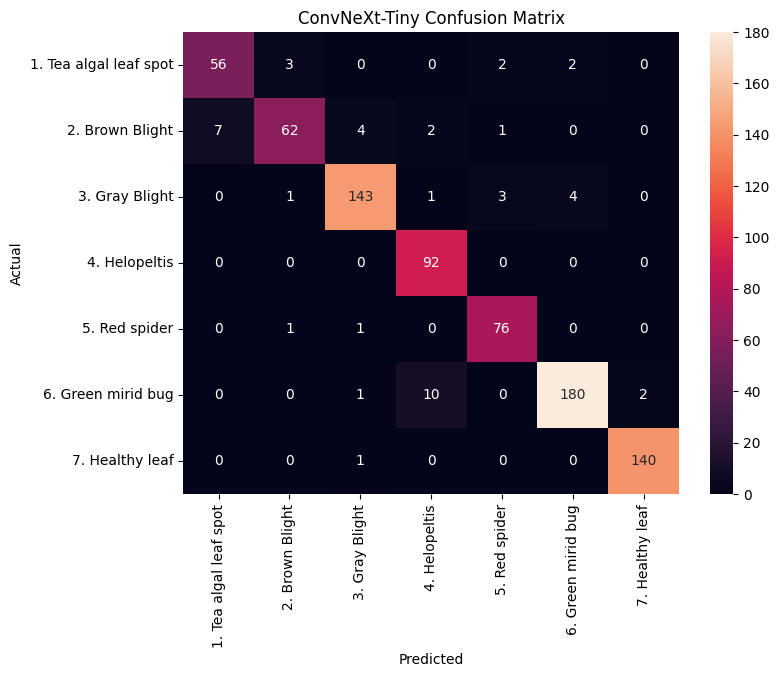

In [71]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(all_labels, all_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(    cm,    annot=True,    fmt="d",    xticklabels=test_dataset.classes,    yticklabels=test_dataset.classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ConvNeXt-Tiny Confusion Matrix")
plt.show()

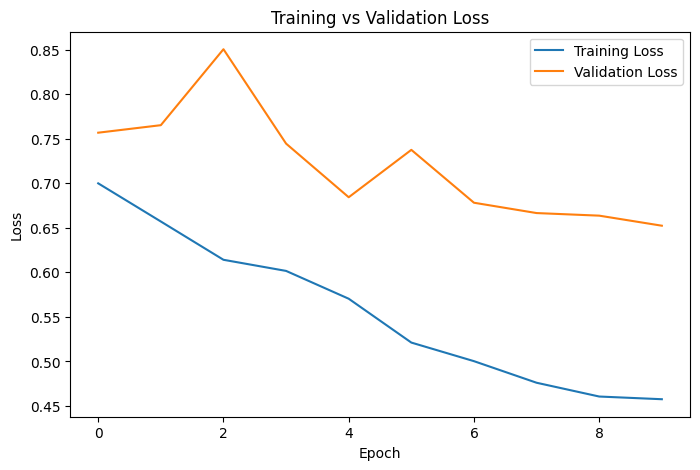

In [73]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

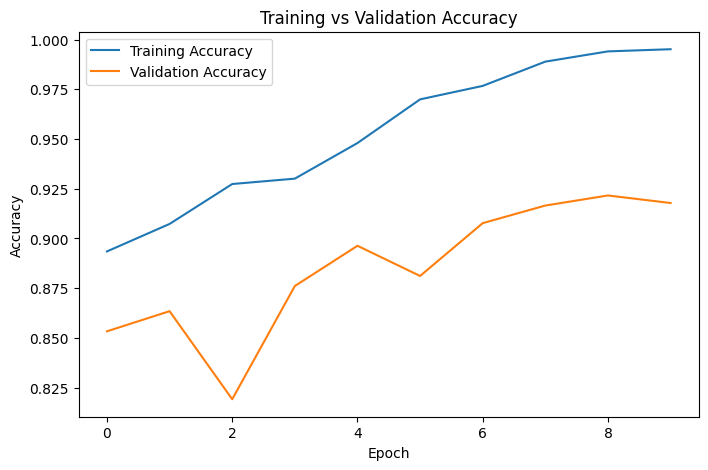

In [75]:
plt.figure(figsize=(8, 5))
plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

In [77]:
# Extra feature not in the ViT version: per-class accuracy bar chart

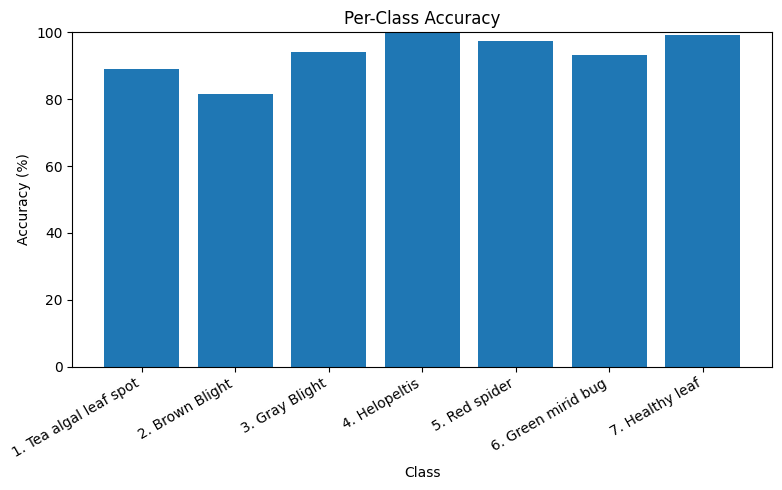

Image: /content/tea_leaf_dataset/test/7. Healthy leaf/healthy_00009.jpg
Actual class: 7. Healthy leaf


In [81]:
import numpy as np
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
per_class_accuracy = cm_norm.diagonal()
plt.figure(figsize=(8, 5))
plt.bar(test_dataset.classes, per_class_accuracy * 100)
plt.xlabel("Class")
plt.ylabel("Accuracy (%)")
plt.title("Per-Class Accuracy")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()
import random
class_name = random.choice(test_dataset.classes)
class_dir = os.path.join(output_dir, "test", class_name)
filename = random.choice(os.listdir(class_dir))
image_path = os.path.join(class_dir, filename)
print("Image:", image_path)
print("Actual class:", class_name)

In [88]:
from PIL import Image
image = Image.open(image_path).convert("RGB")
input_tensor = val_test_transform(image)
input_tensor = input_tensor.unsqueeze(0).to(device)
with torch.no_grad():
  output = model(input_tensor)
  probabilities = torch.softmax(output, dim=1)
  predicted_class = torch.argmax(probabilities, dim=1).item()
  confidence = probabilities[0][predicted_class].item()
  print("Actual:", class_name)
  print("Predicted:", test_dataset.classes[predicted_class])
  print(f"Confidence: {confidence * 100:.2f}%")

Actual: 7. Healthy leaf
Predicted: 7. Healthy leaf
Confidence: 91.70%


In [ ]:
# Extra feature not in the ViT version: persist the trained model + class map# together so the checkpoint is self-describing for later inference.

In [90]:
torch.save({
    "model_state_dict": model.state_dict(),
    "class_to_idx": train_dataset.class_to_idx,
    "img_size": IMG_SIZE,
    "architecture": "convnext_tiny"},
    "/content/convnext_final_package.pth")
print("Saved final model package to /content/convnext_final_package.pth")

Saved final model package to /content/convnext_final_package.pth


## Deploying this model

`convnext_final_package.pth` (downloaded above) contains everything needed for inference:
the trained weights, the `class_to_idx` mapping, the image size, and the architecture name.

To turn this into a working app (e.g. a Streamlit web app), you only need:
1. `timm` and `torch` installed
2. This checkpoint file
3. The same preprocessing transform used for `val_test_transform` above (Resize → ToTensor → Normalize)

A ready-to-use `app.py` + `requirements.txt` for Streamlit Community Cloud deployment has been
provided alongside this notebook — see the accompanying README for the exact steps.


In [91]:
# Download the trained model package to your computer so you can deploy it
# (Colab's /content storage is wiped when the runtime disconnects, so grab this now)
try:
    from google.colab import files
    files.download("/content/convnext_final_package.pth")
except ImportError:
    print("Not running in Colab — file is saved at /content/convnext_final_package.pth")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>